# Pipeline evaluation — LFW benchmark
authors : Lea Carminati, Anthony Miranda

In this notebook, we evaluate our face recognition pipeline on the **Labeled Faces in the Wild (LFW)** public benchmark. This complements the custom dataset evaluation by testing the pipeline on a standardised, widely-used dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import uuid
from collections import defaultdict
from tqdm.notebook import tqdm
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import auc
from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, VectorParams, Distance, Filter, FieldCondition, MatchValue
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import sys
sys.path.append('../')
from detecVisage import FacesDetects_from_bytes
from faceAlignment import align_crop
from embeddings import get_embedding
from eval_tools import numpy_to_bytes, run_pipeline, compute_metrics

In [2]:
MODEL_PATH     = '../model/blaze_face_short_range.tflite'
COLLECTION_LFW = 'face_lfw'
THRESHOLD      = np.arange(0.0, 1.01, 0.01)
N_IMPOSTORS    = 300
RANDOM_SEED    = 42

client = QdrantClient(host="localhost", port=6333)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

## Dataset description

We use the LFW dataset loaded via scikit-learn (`fetch_lfw_people`), filtered to persons with at least 10 photographs.

The dataset is split 80/20 per person:
- **80%** of each person's photos → registered in the Qdrant database
- **20%** → used as genuine evaluation attempts

Impostors are persons present in the full LFW dataset but **not** in the registered set. We sample 300 impostor images at random (seed=42).

In [3]:
lfw = fetch_lfw_people(min_faces_per_person=10, resize=1.0, color=True)

print(f'Registered persons : {len(lfw.target_names)}')
print(f'Total images       : {lfw.images.shape[0]}')
print(f'Image shape        : {lfw.images.shape[1]} x {lfw.images.shape[2]}')
print('\nFirst 10 persons:')
for i, name in enumerate(lfw.target_names[:10]):
    print(f'  {name}: {(lfw.target == i).sum()} photos')

Registered persons : 158
Total images       : 4324
Image shape        : 125 x 94

First 10 persons:
  Abdullah Gul: 19 photos
  Adrien Brody: 12 photos
  Alejandro Toledo: 39 photos
  Alvaro Uribe: 35 photos
  Amelie Mauresmo: 21 photos
  Andre Agassi: 36 photos
  Andy Roddick: 15 photos
  Angelina Jolie: 20 photos
  Ann Veneman: 11 photos
  Anna Kournikova: 12 photos


In [15]:
import cv2
import numpy as np

def numpy_to_bytes(img_array):
    # LFW dà float32 tra 0 e 255, va convertito in uint8
    img_uint8 = (img_array*255).astype(np.uint8)
    # converti RGB -> BGR per OpenCV
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    # encode in JPEG bytes
    _, buffer = cv2.imencode('.jpg', img_bgr)
    return buffer.tobytes()

In [4]:
person_indices = defaultdict(list)
for idx, label in enumerate(lfw.target):
    person_indices[label].append(idx)

db_indices   = []
eval_indices = []

for label, indices in person_indices.items():
    n_db = max(1, int(len(indices) * 0.8))
    db_indices.extend(indices[:n_db])
    eval_indices.extend(indices[n_db:])

print(f'Images in DB    : {len(db_indices)}')
print(f'Images for eval : {len(eval_indices)}')

Images in DB    : 3397
Images for eval : 927


## Database population

We create a dedicated Qdrant collection (`face_lfw`) and register the 80% training images.

In [5]:
existing = client.get_collections().collections
if COLLECTION_LFW not in [c.name for c in existing]:
    client.create_collection(
        collection_name=COLLECTION_LFW,
        vectors_config=VectorParams(size=512, distance=Distance.COSINE)
    )

for label in tqdm(person_indices.keys()):
    indices = person_indices[label]
    n_db = max(1, int(len(indices) * 0.8))

    for idx in indices[:n_db]:
        img_bytes = numpy_to_bytes(lfw.images[idx])
        boxes, detection_result, image = FacesDetects_from_bytes(img_bytes, 'mediapipe', detector)

        if not detection_result or not detection_result.detections:
            continue

        crops = align_crop(image, detection_result)
        if not crops:
            continue

        embedding = get_embedding(crops[0])
        client.upsert(
            collection_name=COLLECTION_LFW,
            points=[PointStruct(
                id=str(uuid.uuid4()),
                vector=embedding.tolist(),
                payload={'name': lfw.target_names[label]}
            )]
        )

print(f'Vectors in DB: {client.count(collection_name=COLLECTION_LFW).count}')

  0%|          | 0/158 [00:00<?, ?it/s]

Vectors in DB: 6762


## Pipeline execution

We run the pipeline on the 20% evaluation split (genuine) and on the sampled impostors.

In [6]:
results_lfw = []
detection_failures = 0

# genuine attempts
for label in tqdm(person_indices.keys(), desc='Genuine'):
    indices = person_indices[label]
    n_db = max(1, int(len(indices) * 0.8))

    for idx in indices[n_db:]:
        img_bytes = numpy_to_bytes(lfw.images[idx])
        result = run_pipeline(
            img_bytes, detector, client, COLLECTION_LFW,
            label_true=lfw.target_names[label], is_genuine=True,
            align_crop_fn=align_crop, get_embedding_fn=get_embedding,
            FacesDetects_fn=FacesDetects_from_bytes
        )
        if result is None:
            detection_failures += 1
        else:
            results_lfw.append(result)

# impostor attempts
lfw_all = fetch_lfw_people(min_faces_per_person=1, resize=1.0, color=True)
registered_names = set(lfw.target_names)
impostor_indices = [i for i, label in enumerate(lfw_all.target)
                    if lfw_all.target_names[label] not in registered_names]

random.seed(RANDOM_SEED)
impostor_sample = random.sample(impostor_indices, N_IMPOSTORS)

for idx in tqdm(impostor_sample, desc='Impostors'):
    img_bytes = numpy_to_bytes(lfw_all.images[idx])
    result = run_pipeline(
        img_bytes, detector, client, COLLECTION_LFW,
        label_true='unknown', is_genuine=False,
        align_crop_fn=align_crop, get_embedding_fn=get_embedding,
        FacesDetects_fn=FacesDetects_from_bytes
    )
    if result is None:
        detection_failures += 1
    else:
        results_lfw.append(result)

genuine_lfw  = [r for r in results_lfw if r['is_genuine']]
impostor_lfw = [r for r in results_lfw if not r['is_genuine']]

print(f'Genuine   : {len(genuine_lfw)}')
print(f'Impostors : {len(impostor_lfw)}')
print(f'Failures  : {detection_failures}')

Genuine:   0%|          | 0/158 [00:00<?, ?it/s]

Impostors:   0%|          | 0/300 [00:00<?, ?it/s]

Genuine   : 921
Impostors : 299
Failures  : 7


## Score distribution

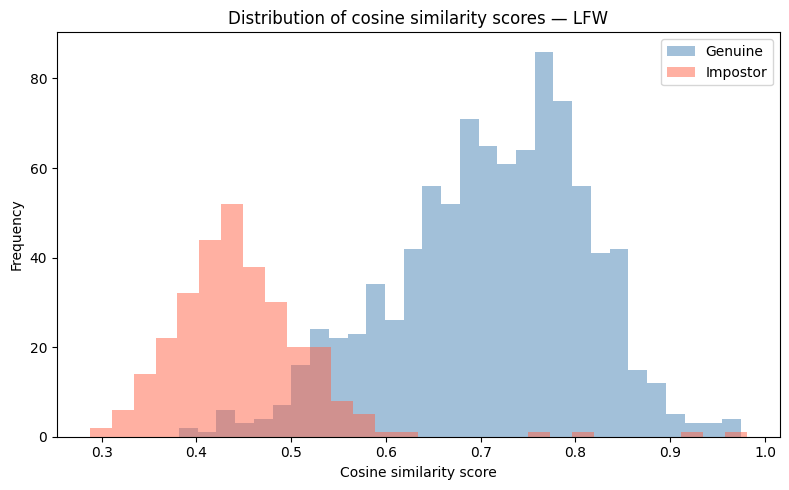

In [7]:
plt.figure(figsize=(8, 5))
plt.hist([r['score'] for r in genuine_lfw],  bins=30, alpha=0.5, label='Genuine',  color='steelblue')
plt.hist([r['score'] for r in impostor_lfw], bins=30, alpha=0.5, label='Impostor', color='tomato')
plt.xlabel('Cosine similarity score')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity scores — LFW')
plt.legend()
plt.tight_layout()
plt.show()

## Biometric evaluation metrics

In [8]:
m = compute_metrics(genuine_lfw, impostor_lfw, THRESHOLD)

print(f'EER           : {m["eer_value"]*100:.2f}%')
print(f'EER threshold : {m["eer_threshold"]:.2f}')
print(f'TAR at EER    : {m["tar"][m["eer_idx"]]*100:.2f}%')
print(f'AUC (ROC)     : {m["auc"]:.4f}')

EER           : 6.76%
EER threshold : 0.54
TAR at EER    : 91.86%
AUC (ROC)     : 0.9500


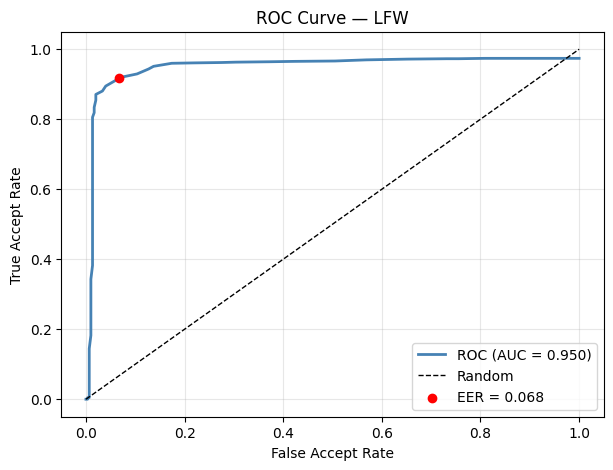

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(m['far'], m['tar'], color='steelblue', lw=2, label=f'ROC (AUC = {m["auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.scatter(m['far'][m['eer_idx']], m['tar'][m['eer_idx']], color='red', zorder=5,
            label=f'EER = {m["eer_value"]:.3f}')
plt.xlabel('False Accept Rate')
plt.ylabel('True Accept Rate')
plt.title('ROC Curve — LFW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

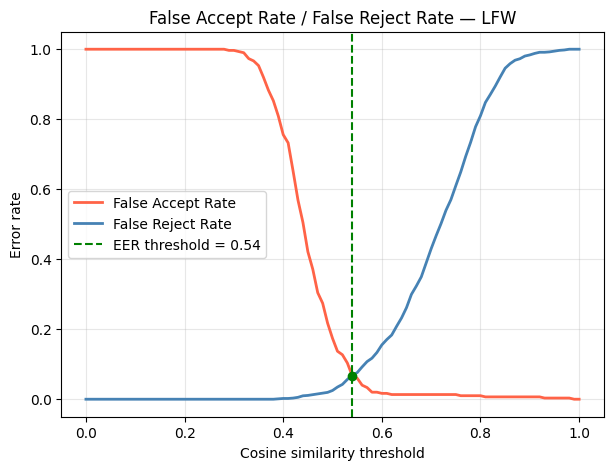

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(THRESHOLD, m['far'], color='tomato',    lw=2, label='False Accept Rate')
plt.plot(THRESHOLD, m['frr'], color='steelblue', lw=2, label='False Reject Rate')
plt.axvline(m['eer_threshold'], color='green', linestyle='--', lw=1.5,
            label=f'EER threshold = {m["eer_threshold"]:.2f}')
plt.scatter(m['eer_threshold'], m['eer_value'], color='green', zorder=5)
plt.xlabel('Cosine similarity threshold')
plt.ylabel('Error rate')
plt.title('False Accept Rate / False Reject Rate — LFW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()